In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_linnerud
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [28]:
data = load_linnerud()

x = pd.DataFrame(data.data, columns=data.feature_names)

y = pd.DataFrame(data.target, columns=data.target_names)

print(x.head())
print(y.head())
print(x.describe())
print(y.describe())

   Chins  Situps  Jumps
0    5.0   162.0   60.0
1    2.0   110.0   60.0
2   12.0   101.0  101.0
3   12.0   105.0   37.0
4   13.0   155.0   58.0
   Weight  Waist  Pulse
0   191.0   36.0   50.0
1   189.0   37.0   52.0
2   193.0   38.0   58.0
3   162.0   35.0   62.0
4   189.0   35.0   46.0
           Chins      Situps      Jumps
count  20.000000   20.000000   20.00000
mean    9.450000  145.550000   70.30000
std     5.286278   62.566575   51.27747
min     1.000000   50.000000   25.00000
25%     4.750000  101.000000   39.50000
50%    11.500000  122.500000   54.00000
75%    13.250000  210.000000   85.25000
max    17.000000  251.000000  250.00000
           Weight      Waist      Pulse
count   20.000000  20.000000  20.000000
mean   178.600000  35.400000  56.100000
std     24.690505   3.201973   7.210373
min    138.000000  31.000000  46.000000
25%    160.750000  33.000000  51.500000
50%    176.000000  35.000000  55.000000
75%    191.500000  37.000000  60.500000
max    247.000000  46.000000  74

In [29]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

print(x_scaled.head())

      Chins    Situps     Jumps
0 -0.863671  0.269750 -0.206086
1 -1.445921 -0.582956 -0.206086
2  0.494912 -0.730539  0.614257
3  0.494912 -0.664946 -0.666279
4  0.688996  0.154963 -0.246103


In [30]:
target_scaler = StandardScaler()

y_scaled = target_scaler.fit_transform(y)

y_scaled = pd.DataFrame(y_scaled, columns=y.columns)

print(y_scaled.head())

     Weight     Waist     Pulse
0  0.515264  0.192252 -0.867981
1  0.432157  0.512673 -0.583397
2  0.598371  0.833094  0.270355
3 -0.689789 -0.128168  0.839523
4  0.432157 -0.128168 -1.437149


In [31]:
pca = PCA(n_components=1)

y_pca = pca.fit_transform(y_scaled)

y_pca = pd.Series(y_pca.flatten(), name='PC1_Target')

print(y_pca.head())
print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')

0    0.817805
1    0.850706
2    0.806126
3   -0.877171
4    0.796896
Name: PC1_Target, dtype: float64
Explained Variance Ratio: [0.70137682]


In [32]:
y_waist = y_scaled['Waist']
print(y_waist.head())

0    0.192252
1    0.512673
2    0.833094
3   -0.128168
4   -0.128168
Name: Waist, dtype: float64


In [33]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(alpha=1.0),
    'Lasso' : Lasso(alpha=0.1)
}

def evaluate_models(x, y, scenario_name):
    results = []

    for model_name, model, in models.items():

        model.fit(x,y)

        predictions = model.predict(x)

        mse = mean_squared_error(y, predictions)
        r2 = r2_score(y, predictions)

        results.append({
            'Scenario' : scenario_name,
            'Model' : model_name,
            'MSE' : mse,
            'R2 Score' : r2
        })
    return results

results_pca = evaluate_models(x_scaled, y_pca, 'PCA Target')

results_waist = evaluate_models(x_scaled, y_waist, 'Waist Target')

results_df = pd.DataFrame(
    results_pca + results_waist
)

print(results_df)

       Scenario              Model       MSE  R2 Score
0    PCA Target  Linear Regression  1.268880  0.396958
1    PCA Target              Ridge  1.275908  0.393618
2    PCA Target              Lasso  1.332376  0.366781
3  Waist Target  Linear Regression  0.452156  0.547844
4  Waist Target              Ridge  0.456687  0.543313
5  Waist Target              Lasso  0.515654  0.484346


In [34]:
pca_features = PCA(n_components=2)

x_pca = pca_features.fit_transform(x_scaled)

x_pca_df = pd.DataFrame(x_pca, columns=['PC1','PC2'])

print(x_pca_df.head())

        PC1       PC2
0 -0.435419  0.421856
1 -1.286072  0.851848
2  0.171390  0.147083
3 -0.497869 -0.796676
4  0.346792 -0.653763


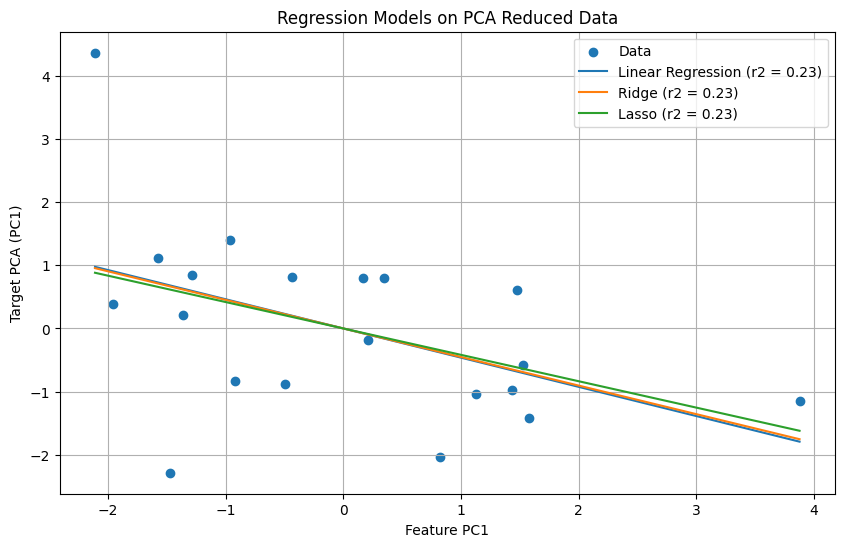

In [35]:
x_pc1 = x_pca_df[['PC1']]

plt.figure(figsize=(10,6))

plt.scatter(x_pc1, y_pca, label='Data')

for model_name, model in models.items():

    model.fit(x_pc1, y_pca)

    predictions = model.predict(x_pc1)

    r2 = r2_score(y_pca, predictions)

    sorted_idx = np.argsort(x_pc1.values.flatten())

    plt.plot(x_pc1.values.flatten()[sorted_idx], predictions[sorted_idx], label = f'{model_name} (r2 = {r2:.2f})')

plt.xlabel("Feature PC1")
plt.ylabel("Target PCA (PC1)")
plt.title("Regression Models on PCA Reduced Data")

plt.legend()
plt.grid(True)

plt.show()